In [2]:
import json

with open("/home/imruhi/Documents/RiskPerceptionSeafare/params.json", 'r') as f:
    PARAMS = json.load(f)


In [ ]:
from datasets import Dataset
import pandas as pd
from sklearn.neighbors import BallTree
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data_path = f'{PARAMS["roberta_data_path"]}_{PARAMS["word_window"]}_filtered'
    
dataset = Dataset.load_from_disk(data_path).to_pandas().reset_index(drop=True)

In [ ]:
def level_shipwreck(count, b1, b2, b3, b4):
    if 0 < count <= b1:
        return "VERYLOW"
    elif b1 < count <= b2:
        return "LOW"
    elif b2 < count <= b3:
        return "MEDIUM"
    elif b3 < count <= b4:
        return "HIGH"
    elif b4 < count:
        return "VERYHIGH"
    else:
        return "COUNT_MISSING"

In [12]:
def get_df():
    geodatabase_shipwrecks = pd.read_excel(PARAMS["shipwreck_path"], sheet_name='GeoDatabase', header=1).drop(columns='Unnamed: 0')
    len_original = len(geodatabase_shipwrecks)
    geodatabase_shipwrecks = geodatabase_shipwrecks[geodatabase_shipwrecks['Latitude'].notna() & geodatabase_shipwrecks['Longitude'].notna()]
    remove = []
    missing = 1
    for idx, row in geodatabase_shipwrecks.iterrows():
        try:
            lat, long = float('{:,.1f}'.format(row['Latitude'])), float('{:,.1f}'.format(row['Longitude']))            
        except:
            missing+=1
            remove.append(idx)
    geodatabase_shipwrecks = geodatabase_shipwrecks.drop(remove)
    geodatabase_shipwrecks["Latitude"] = [float(x) for x in geodatabase_shipwrecks["Latitude"]]
    geodatabase_shipwrecks["Longitude"] = [float(x) for x in geodatabase_shipwrecks["Longitude"]]

    print(f"{len_original-len(geodatabase_shipwrecks)+missing} shipwrecks (of {len_original}) do not have lat and long")
    
    return geodatabase_shipwrecks
    

def link(low, high):
    geodatabase_shipwrecks = get_df()
    all_excerpts = Dataset.load_from_disk(PARAMS["dataset_extracted"]).to_pandas()
    print(all_excerpts.columns)
    all_ports_aoe_topos = pd.read_csv(PARAMS["all_ports_aoe_topos"])
    len_original = len(all_ports_aoe_topos)

    coord_port = all_ports_aoe_topos[["LATITUDE", "LONGITUDE", "newOBJECTID"]].dropna().reset_index(drop=True)
    print(f"{len_original-len(coord_port)} ports do not have lat and long")

    port_aoe = all_ports_aoe_topos[["newOBJECTID", "AoE"]]
    port_aoe = port_aoe.set_index('newOBJECTID')["AoE"].to_dict()

    # connect shipwrecks to ports (using lat long)
        # Convert to radians (required for haversine distance)
    df1_rad = np.radians(coord_port[['LATITUDE', 'LONGITUDE']])
    df2_rad = np.radians(geodatabase_shipwrecks[['Latitude', 'Longitude']])

    # Build BallTree
    tree = BallTree(df1_rad, metric='haversine')

    # Query nearest neighbor
    dist, ind = tree.query(df2_rad, k=1)
    geodatabase_shipwrecks['newOBJECTID'] = coord_port.iloc[ind.flatten()]['newOBJECTID'].values
    geodatabase_shipwrecks["AoE"] = [port_aoe[x] for x in geodatabase_shipwrecks["newOBJECTID"]]
    object_id_port = all_ports_aoe_topos.set_index('newOBJECTID')["NAME"].to_dict()
    # for display purposes
    geodatabase_shipwrecks["port_name"] = [object_id_port[x].split(', ')[0] for x in geodatabase_shipwrecks["newOBJECTID"]]
    return geodatabase_shipwrecks

In [39]:
geodatabase_shipwrecks = link(10, 45)

27 shipwrecks (of 1936) do not have lat and long
Index(['workID', 'text', 'location', 'auth_title_display', 'no_context_text',
       'type', 'category', 'original_lang', 'newOBJECTID', 'edate',
       'paragraph_id', 'placeID', 'index_id', 'AoE'],
      dtype='str')
0 ports do not have lat and long


In [41]:
geodatabase_shipwrecks = geodatabase_shipwrecks[["newOBJECTID", "AoE"]]

In [44]:
port_shipwrecks_ = geodatabase_shipwrecks.groupby("newOBJECTID")["newOBJECTID"].count().reset_index(name="count")

In [51]:
all_ports_aoe_topos = pd.read_csv(PARAMS["all_ports_aoe_topos"])

In [60]:
port_coords = all_ports_aoe_topos[["LATITUDE", "LONGITUDE", "newOBJECTID", "AoE"]]

In [61]:
knn_df = port_shipwrecks_.merge(port_coords, on="newOBJECTID")

In [64]:
aoe_dict = {"GulfLion":0, "TyrrhenianCoastIT":1, "CapeBonAlexandria":2}

In [65]:
knn_df["AoE"] = [aoe_dict[x] for x in knn_df["AoE"]]

In [66]:
knn_df

,newOBJECTID,count,LATITUDE,LONGITUDE,AoE
0,0,130,42.267400,3.169100,0
1,1,15,42.519556,3.108357,0
2,3,5,42.708809,2.945258,0
3,4,36,43.180100,3.014200,0
4,5,27,43.314327,3.468434,0
...,...,...,...,...,...
68,147,59,38.944800,16.238900,1
69,149,1,38.722200,16.072300,1
70,151,2,38.482100,15.988200,1
71,153,1,38.259000,15.715000,1


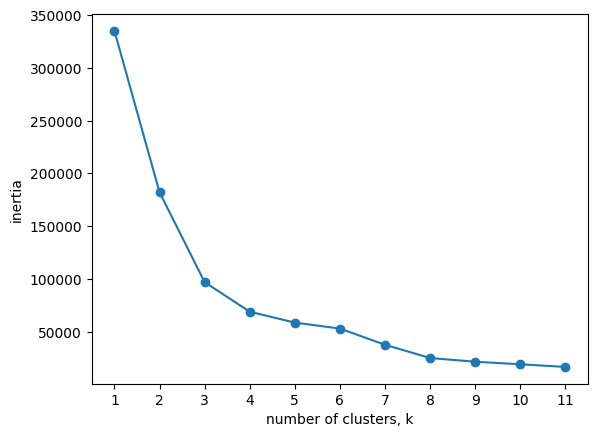

In [77]:
ks = range(1, 12)
inertias = []
for k in ks:
    # Create a KMeans instance with k clusters: model
    model = KMeans(n_clusters=k, random_state=42)
    
    # Fit model to samples
    model.fit(knn_df)
    
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)
    
# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [78]:
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(knn_df)
knn_df["label"] = kmeans.labels_
knn_df["label"].value_counts()

label
4    25
0    24
1    16
2     7
3     1
Name: count, dtype: int64

In [79]:
knn_df

,newOBJECTID,count,LATITUDE,LONGITUDE,AoE,label
0,0,130,42.267400,3.169100,0,2
1,1,15,42.519556,3.108357,0,1
2,3,5,42.708809,2.945258,0,1
3,4,36,43.180100,3.014200,0,1
4,5,27,43.314327,3.468434,0,1
...,...,...,...,...,...,...
68,147,59,38.944800,16.238900,1,4
69,149,1,38.722200,16.072300,1,4
70,151,2,38.482100,15.988200,1,4
71,153,1,38.259000,15.715000,1,4


In [89]:
all_excerpts = Dataset.load_from_disk(PARAMS["dataset_extracted"]).to_pandas()
port_shipwrecks_ = geodatabase_shipwrecks.groupby("newOBJECTID").size().reset_index(name="num_shipwrecks")
port_shipwrecks_["level_shipwreck"] = [level_shipwreck(int(x), b1=20, b2=30, b3=50, b4=100) for x in port_shipwrecks_["num_shipwrecks"]]
port_shipwrecks = port_shipwrecks_[["newOBJECTID", "level_shipwreck"]]
port_shipwrecks = port_shipwrecks.set_index('newOBJECTID')["level_shipwreck"].to_dict()
possible_ports = list(port_shipwrecks.keys())
all_excerpts_ = all_excerpts.query("newOBJECTID in @possible_ports")
all_excerpts_["level_shipwreck"] = [port_shipwrecks[x] for x in all_excerpts_["newOBJECTID"]]
port_shipwrecks = port_shipwrecks_[["newOBJECTID", "num_shipwrecks"]]
port_shipwrecks_num = port_shipwrecks.set_index('newOBJECTID')["num_shipwrecks"].to_dict()
all_excerpts_["num_shipwrecks"] = [port_shipwrecks_num[x] for x in all_excerpts_["newOBJECTID"]]
all_excerpts_["level_shipwreck"].value_counts()


level_shipwreck
MEDIUM      11633
VERYLOW      3790
VERYHIGH     1412
HIGH          369
LOW            18
Name: count, dtype: int64